In [1]:
import os
os.chdir('../../../..')

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import combinations
from tqdm import tqdm
from skbio.stats.distance import mantel

from src.datasets import QM9Dataset
from src.non_euclidean import Riemann, Grassmann, Wasserstein

In [3]:
qm9 = QM9Dataset(limit=1500, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["mace", "acsf", "transformer", "chemprop", "soap", "onehot", "morgan"])
df = qm9.load()

2026-05-12 11:31:23.256 | INFO     | src.datasets:_load_full_qm9_df:816 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-12 11:31:23.866 | INFO     | src.datasets:_sample_qm9_df:999 - QM9 sampling complete: strategy=stratified, requested_limit=1500, returned_rows=1500, sampling on columns=['num_atoms', 'gap'].
2026-05-12 11:31:23.867 | INFO     | src.datasets:_add_requested_descriptors:201 - Applying requested QM9 descriptors to sampled dataframe (rows=1500).
2026-05-12 11:31:23.868 | INFO     | src.features:compute_mace_outputs:678 - Computing MACE embeddings (model=medium, batch_size=32)...
/Users/karlfindhansen/thesis/Anomaly-Detection-in-Molecular-and-Materials-Datasets/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using MACE-OFF23 MODEL for MACECalculator with /Users/karlfindhansen/.cache/mace/MACE-OFF23_medium.model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


2026-05-12 11:32:35.533 | SUCCESS  | src.datasets:add_mace:1235 - Added MACE embeddings and matrices.
2026-05-12 11:32:35.535 | INFO     | src.features:compute_acsf_outputs:537 - Computing ACSF (rcut=6.0, normalize=True)...
2026-05-12 11:32:36.200 | SUCCESS  | src.datasets:add_acsf:1211 - Added ACSF embeddings and matrices.
2026-05-12 11:32:36.200 | INFO     | src.features:compute_selfies_transformer:242 - Computing SELFormer Embeddings using HUBioDataLab/SELFormer...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

2026-05-12 11:32:45.220 | INFO     | src.features:compute_chemprop_embeddings:709 - Computing Chemprop embeddings on mps...
2026-05-12 11:32:45.224 | INFO     | scripts.qm9.chemprop:__init__:28 - Initializing CheMeleonFingerprint generator...
2026-05-12 11:32:45.225 | INFO     | scripts.qm9.chemprop:__init__:48 - Found existing CheMeleon weights at /Users/karlfindhansen/.chemprop/chemeleon_mp.pt
2026-05-12 11:32:45.273 | SUCCESS  | scripts.qm9.chemprop:__init__:54 - Successfully loaded CheMeleon message passing weights.
2026-05-12 11:32:45.279 | INFO     | scripts.qm9.chemprop:__call__:75 - Generating CheMeleon fingerprints for 1500 molecules...
2026-05-12 11:32:47.889 | SUCCESS  | scripts.qm9.chemprop:__call__:100 - Successfully generated 1500 fingerprints of dimension 2048.
2026-05-12 11:32:47.903 | INFO     | src.features:compute_soap_outputs:394 - Computing SOAP (rcut=6.0, nmax=8, lmax=6, normalize=True)...
2026-05-12 11:32:48.900 | SUCCESS  | src.datasets:add_soap:1192 - Added SOA

In [4]:
onehot_matrix = qm9.get_distance_matrix(
    descriptor='onehot',
    dist_type="jaccard",
)

morgan_matrix = qm9.get_distance_matrix(
    descriptor='morgan',
    dist_type="jaccard",
)

soap_matrix = qm9.get_distance_matrix(
    descriptor='soap',
    dist_type="soap_kernel",
)

acsf_matrix = qm9.get_distance_matrix(
    descriptor='acsf',
    dist_type="euclidean",
)

transformer_matrix = qm9.get_distance_matrix(
    descriptor='transformer',
    dist_type="euclidean",
    pca_components=8,
)

chemprop_matrix = qm9.get_distance_matrix(
    descriptor='chemprop',
    dist_type="euclidean",
    pca_components=8,
)

mace_matrix = qm9.get_distance_matrix(
    descriptor='mace',
    dist_type="euclidean",
    pca_components=8,
)

2026-05-12 11:32:51.488 | INFO     | src.datasets:get_distance_matrix:1325 - Calculating distance matrix for onehot using jaccard distance.
2026-05-12 11:32:52.326 | INFO     | src.datasets:get_distance_matrix:1325 - Calculating distance matrix for morgan using jaccard distance.
2026-05-12 11:32:53.950 | INFO     | src.datasets:get_distance_matrix:1325 - Calculating distance matrix for soap using soap_kernel distance.
2026-05-12 11:32:53.975 | INFO     | src.datasets:get_distance_matrix:1325 - Calculating distance matrix for acsf using euclidean distance.
2026-05-12 11:32:54.035 | INFO     | src.datasets:get_distance_matrix:1308 - Applying PCA to reduce 'transformer' to 8 dimensions.
2026-05-12 11:32:54.055 | INFO     | src.datasets:get_distance_matrix:1312 - PCA kept 62.48% of the variance for 'transformer'.
2026-05-12 11:32:54.055 | INFO     | src.datasets:get_distance_matrix:1314 - PCA reduced 'transformer' dimensions from 768 to 8
2026-05-12 11:32:54.060 | INFO     | src.datasets:g

In [5]:
matrices = {
    "OneHot": onehot_matrix,
    "Morgan": morgan_matrix,
    "SOAP": soap_matrix,
    "ACSF": acsf_matrix,
    "Transformer": transformer_matrix,
    "Chemprop": chemprop_matrix
}

def mantel_dist_correlation(matrices):
    names = list(matrices.keys())
    n = len(names)

# Initialize results matrix with 1.0 on the diagonal 
# (a metric perfectly correlates with itself)
    results = np.zeros((n, n))
    np.fill_diagonal(results, 1.0)

# Generate all unique pairs of indices (e.g., (0,1), (0,2)...)
# This prevents calculating A vs B and then redundantly calculating B vs A
    pairs = list(combinations(range(n), 2))

# Define the worker function for the parallel pool
    def compute_pair(i, j):
        """
    Runs the scikit-bio mantel test on a pair of matrices.
    """
    # 1. Cast the matrices to 64-bit floats (C 'double'). 
    # This simultaneously creates a writable copy, bypassing joblib's lock.
        mat_i = matrices[names[i]].astype(np.float64)
        mat_j = matrices[names[j]].astype(np.float64)
    
    # 2. Ensure the matrices are strictly "hollow" (diagonal == 0.0)
        np.fill_diagonal(mat_i, 0.0)
        np.fill_diagonal(mat_j, 0.0)

    # 3. Run the optimized mantel test
        r, p, _ = mantel(
        mat_i, 
        mat_j, 
        method='pearson', 
        permutations=999 
    )
        return i, j, r

    print(f"Executing {len(pairs)} pairwise Mantel comparisons...")


# Loop through the pairs one by one using tqdm for a progress bar
    for i, j in tqdm(pairs, desc="Computing pairs"):
    # Run the compute function
        _, _, r = compute_pair(i, j)
    
    # Immediately assign the result to the matrix (mirroring across the diagonal)
        results[i, j] = results[j, i] = r

# Convert to DataFrame for visualization
    mantel_df = pd.DataFrame(results, index=names, columns=names)
    return mantel_df, names

mantel_df, names = mantel_dist_correlation(matrices)

print("\nFinal Mantel Correlation Matrix:")
print(mantel_df)

Executing 15 pairwise Mantel comparisons...


Computing pairs: 100%|██████████| 15/15 [00:19<00:00,  1.28s/it]


Final Mantel Correlation Matrix:
               OneHot    Morgan      SOAP      ACSF  Transformer  Chemprop
OneHot       1.000000  0.153271  0.081366  0.062273     0.094726  0.360344
Morgan       0.153271  1.000000  0.363249  0.388545     0.342187  0.473719
SOAP         0.081366  0.363249  1.000000  0.671964     0.306116  0.529562
ACSF         0.062273  0.388545  0.671964  1.000000     0.249269  0.530684
Transformer  0.094726  0.342187  0.306116  0.249269     1.000000  0.433595
Chemprop     0.360344  0.473719  0.529562  0.530684     0.433595  1.000000


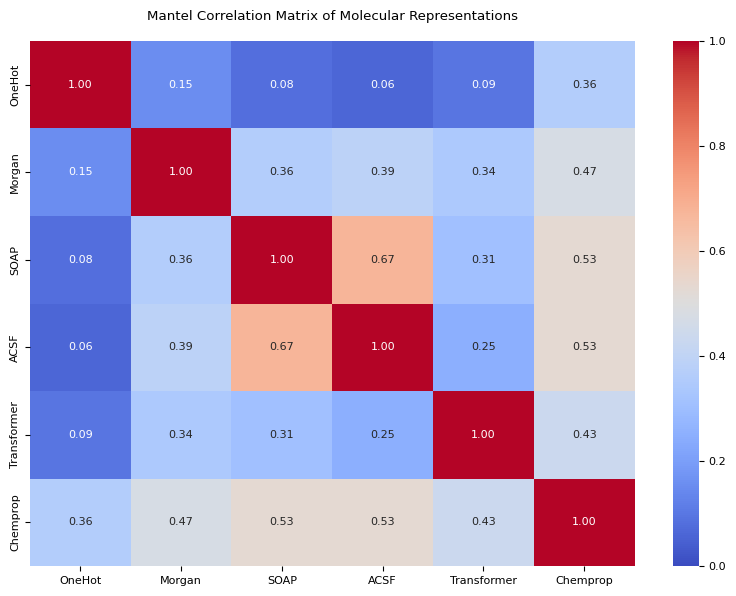

In [6]:
df_mantel = pd.DataFrame(mantel_df, index=names)
plt.figure(figsize=(8, 6))
sns.heatmap(df_mantel, annot=True, cmap="coolwarm", fmt=".2f", vmin=0, vmax=1)
plt.title("Mantel Correlation Matrix of Molecular Representations", pad=15)
plt.tight_layout()
#plt.savefig("mantel_heatmap.png", dpi=300)
plt.show()

In [ ]:
riemann = Riemann()
grassmann = Grassmann()
wasserstein = Wasserstein()

soap_euclidean = qm9.get_distance_matrix(descriptor="soap", dist_type="euclidean", pca_components=4)
riemann_dist_matrix_soap = riemann.distance_matrix(df=df, descriptor="soap", pca_components=4))
wasserstein_dist_matrix_soap = wasserstein.distance_matrix(df=df, descriptor="soap", metric='euclidean')
average_kernel_dist_matrix = qm9.get_distance_matrix(descriptor="soap_matrix", dist_type="average_kernel")
rematch_kernel_dist_matrix = qm9.get_distance_matrix(descriptor="soap_matrix", dist_type="rematch_kernel")

2026-05-12 11:36:23.960 | INFO     | src.datasets:get_distance_matrix:1308 - Applying PCA to reduce 'soap' to 4 dimensions.
2026-05-12 11:36:23.964 | INFO     | src.datasets:get_distance_matrix:1312 - PCA kept 94.27% of the variance for 'soap'.


2026-05-12 11:36:23.965 | INFO     | src.datasets:get_distance_matrix:1314 - PCA reduced 'soap' dimensions from 252 to 4
2026-05-12 11:36:23.972 | INFO     | src.datasets:get_distance_matrix:1325 - Calculating distance matrix for soap using euclidean distance.
2026-05-12 11:36:23.981 | INFO     | src.non_euclidean:distance_matrix:1107 - Computing Riemann distance matrix | Features: soap | Distance: affine-invariant
2026-05-12 11:36:23.981 | INFO     | src.non_euclidean:_feature_matrices_from_df:331 - Using column: soap_matrix from df
2026-05-12 11:36:24.336 | INFO     | src.non_euclidean:matrix_pca:1068 - Applying PCA to reduce feature dimension to 5...
2026-05-12 11:36:24.361 | INFO     | src.non_euclidean:matrix_pca:1083 - PCA explained variance ratio: 0.8460 (cumulative for 5 components)
2026-05-12 11:36:24.370 | INFO     | src.non_euclidean:distance_matrix:1118 - Computing affine-invariant distances...
2026-05-12 11:36:25.684 | INFO     | src.non_euclidean:_feature_matrices_from_df

In [15]:
grassmann_dist_matrix_soap = grassmann.distance_matrix(df=df, descriptor="soap", k=2)

matrices = {
    "Riemann SOAP": riemann_dist_matrix_soap,
    "Grassmann SOAP": grassmann_dist_matrix_soap,
    "Wasserstein SOAP": wasserstein_dist_matrix_soap,
    "Average Kernel": average_kernel_dist_matrix,
    "Rematch Kernel": rematch_kernel_dist_matrix,
    "SOAP Euclidean": soap_euclidean,
}


2026-05-12 11:43:09.785 | INFO     | src.non_euclidean:_feature_matrices_from_df:331 - Using column: soap_matrix from df
2026-05-12 11:43:10.752 | INFO     | src.non_euclidean:distance_matrix:993 - Computing Grassmann distance matrix | Features: soap | Distance: geodesic | k: 2
Grassmann distances: 100%|██████████| 1500/1500 [00:11<00:00, 131.72row/s]


In [17]:
mantel_df, names = mantel_dist_correlation(matrices)

Executing 15 pairwise Mantel comparisons...


Computing pairs: 100%|██████████| 15/15 [00:20<00:00,  1.38s/it]


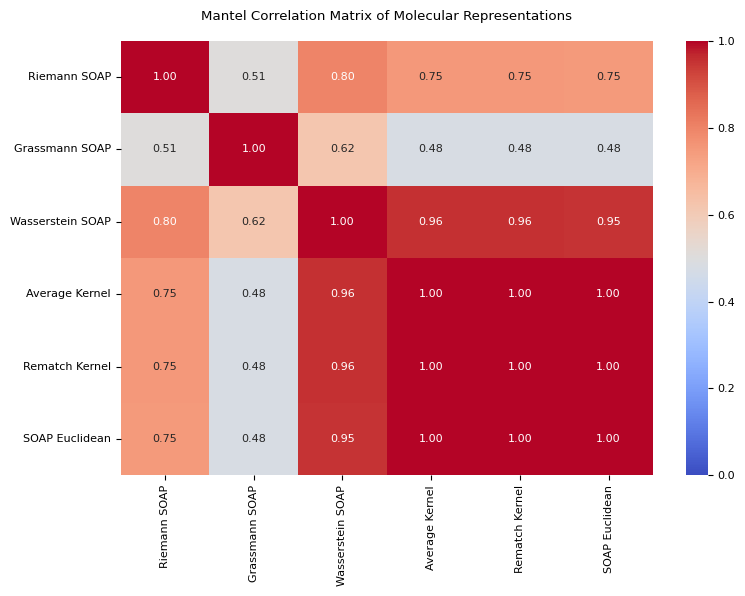

In [18]:
df_mantel = pd.DataFrame(mantel_df, index=names)
plt.figure(figsize=(8, 6))
sns.heatmap(df_mantel, annot=True, cmap="coolwarm", fmt=".2f", vmin=0, vmax=1)
plt.title("Mantel Correlation Matrix of Molecular Representations", pad=15)
plt.tight_layout()
#plt.savefig("mantel_heatmap.png", dpi=300)
plt.show()